## Question 1

In [1]:
import numpy as np

def generer_approbation_profil(n, m, polarisation = 0.0, bruit = 0.05): # n = nombre de votantes, m = nombre de candidates
    
    a = np.random.randint(0, 2, m)
    a_barre = 1 - a
    profil = []

    for _ in range(n):

        if np.random.rand() < (1-polarisation):
            vote = a.copy()
        else:
            if np.random.choice([True, False]):
                vote = a_barre.copy()
            else:
                vote = a.copy()
        
        # ajout du bruit
        for j in range(m):
            if np.random.rand() < bruit:
                vote[j] = 1 - vote[j]
        
        profil.append(vote)

    return np.array(profil)

# Exemple :
#Très peu polarisé :
if __name__ == "__main__":
    p = generer_approbation_profil(n=10, m=5, polarisation=0.0, bruit=0)
    print("Profil très peu polarisé")
    print(p)

#Très polarisé :
if __name__ == "__main__":
    p = generer_approbation_profil(n=10, m=5, polarisation=1.0, bruit=0)
    print("Profil très polarisé")
    print(p)


Profil très peu polarisé
[[1 0 1 0 1]
 [1 0 1 0 1]
 [1 0 1 0 1]
 [1 0 1 0 1]
 [1 0 1 0 1]
 [1 0 1 0 1]
 [1 0 1 0 1]
 [1 0 1 0 1]
 [1 0 1 0 1]
 [1 0 1 0 1]]
Profil très polarisé
[[1 1 1 1 1]
 [0 0 0 0 0]
 [1 1 1 1 1]
 [0 0 0 0 0]
 [1 1 1 1 1]
 [1 1 1 1 1]
 [1 1 1 1 1]
 [0 0 0 0 0]
 [0 0 0 0 0]
 [0 0 0 0 0]]


## Question 2

In [2]:
def generer_ordre_profil(n, m, polarisation = 0.0, bruit = 0.00):

    ordre = np.random.permutation(m)
    ordre_barre = ordre[::-1]
    
    profil = []

    for _ in range(n):

        if np.random.rand() < (1-polarisation):
            vote = ordre.copy()
        else:
            if np.random.choice([True, False]):
                vote = ordre_barre.copy()
            else:
                vote = ordre.copy()

        if np.random.rand() < bruit:
            i, j = np.random.choice(m, 2, replace=False)
            vote[i], vote[j] = vote[j], vote[i]

        profil.append(vote)

    return np.array(profil)

# Exemple :
#Très peu polarisé :
if __name__ == "__main__":
    p = generer_ordre_profil(n=10, m=5, polarisation=0.0, bruit=0)
    print("Profil très peu polarisé")
    print(p)

#Très polarisé :
if __name__ == "__main__":
    p = generer_ordre_profil(n=10, m=5, polarisation=1.0, bruit=0)
    print("Profil très polarisé")
    print(p)


Profil très peu polarisé
[[2 3 1 0 4]
 [2 3 1 0 4]
 [2 3 1 0 4]
 [2 3 1 0 4]
 [2 3 1 0 4]
 [2 3 1 0 4]
 [2 3 1 0 4]
 [2 3 1 0 4]
 [2 3 1 0 4]
 [2 3 1 0 4]]
Profil très polarisé
[[1 0 3 4 2]
 [2 4 3 0 1]
 [2 4 3 0 1]
 [1 0 3 4 2]
 [1 0 3 4 2]
 [2 4 3 0 1]
 [2 4 3 0 1]
 [2 4 3 0 1]
 [1 0 3 4 2]
 [2 4 3 0 1]]


## Question 3

In [3]:
from enum import Enum
import numpy as np

class TypeDeVote(Enum):
    APPROBATION = 0
    ORDRE_TOTAUX = 1

def nbr_votantes_pref(profil, k, l, type_de_vote):
    """Étant donné un profil et deux candidates d'indice k et l, cette méthode 
    retourne de nombre de votantes qui préfèrent ck à cl, étant donné le type de vote.
    """
    match type_de_vote:
        case TypeDeVote.APPROBATION:
            return np.sum((profil[:,k] == 1) & (profil[:,l] == 0))
        case TypeDeVote.ORDRE_TOTAUX:
            n_kl = 0
            for vote in profil:
                position_k = np.where(vote == k)[0][0]
                position_l = np.where(vote == l)[0][0]
                if position_k < position_l:
                    n_kl += 1
            return n_kl


def diff_absolue(profil, k, l, type_de_vote):
    n_kl = nbr_votantes_pref(profil, k, l, type_de_vote)
    n_lk = nbr_votantes_pref(profil, l, k, type_de_vote)
    return abs(n_kl - n_lk)


def ensemble_des_diff_absolue(profil, type_de_vote):
    n, m = profil.shape
    d_valeurs = []
    for k in range(m):
        for l in range(k+1, m):
            d = diff_absolue(profil, k, l, type_de_vote)
            d_valeurs.append(d)
    return np.array(d_valeurs)


def ensemble_des_diff_absolue_approbation(profil):
    return ensemble_des_diff_absolue(profil, TypeDeVote.APPROBATION)


def ensemble_des_diff_absolue_ordre_totaux(profil):
        return ensemble_des_diff_absolue(profil, TypeDeVote.ORDRE_TOTAUX)


#Exemple : 
if __name__ == "__main__":
    p = generer_approbation_profil(n=10, m=5, polarisation=1.0)
    print(ensemble_des_diff_absolue_approbation(p))

        
#Exemple : 
if __name__ == "__main__":
    p = generer_ordre_profil(n=10, m=5, polarisation=1.0)
    print(ensemble_des_diff_absolue_ordre_totaux(p))
            


[2 1 1 0 1 1 2 0 1 1]
[2 2 2 2 2 2 2 2 2 2]


## Question 8 : 

In [4]:
def distance_hamming(a, b):
    # a ^ b est le XOR bit à bit de a et b: contient des 1 aux positions où a et b diffèrent, et des 0 aux positions où a et b sont identiques.
    return int(np.sum(a ^ b))

In [5]:
def distance_spearman(a, b):
    return np.sum(abs(np.subtract(a, b)))

## Question 12

In [6]:
import random

def calcul_consensus_approbation(profil):
    
    n,m = profil.shape
    consensus = [0]*m

    for col in range(m):

        somme = sum(vote[col] for vote in profil)

        if somme > n/2: 
            consensus[col] = 1
        elif somme < n/2: 
            consensus[col] = 0  
        else:
            consensus[col] = random.randint(0,1) 

    return consensus

    
def calcul_u1_approbation(profil):
    consensus = calcul_consensus_approbation(profil)
    u1 = sum([distance_hamming(vote, consensus) for vote in profil])
    return u1

profil = generer_approbation_profil(n=6, m=10, polarisation=0.3)
consensus = calcul_consensus_approbation(profil=profil)
u1 = calcul_u1_approbation(profil=profil)
print("profil:\n", profil)
print("consensus:", consensus)
print("u1:", u1)

profil:
 [[0 0 1 1 1 0 0 0 0 1]
 [0 0 1 1 1 0 0 0 0 1]
 [0 0 0 1 1 0 1 0 0 1]
 [0 0 1 1 1 0 0 0 0 1]
 [1 1 0 0 0 1 1 1 1 0]
 [0 0 1 1 1 0 0 0 0 1]]
consensus: [0, 0, 1, 1, 1, 0, 0, 0, 0, 1]
u1: 12


In [7]:
from scipy.optimize import linear_sum_assignment

def calcul_consensus_ordre(profil):

    n, m = profil.shape

    poids = np.zeros((m,m))
    for candidat in range(m):
        for rang_possible in range(m):

            pds = 0
            for vote in profil:
                index = int(np.where(vote == candidat)[0][0])
                absolue = abs(index - rang_possible)
                pds += absolue

            poids[candidat][rang_possible] = pds

    candidate_ind, rank_ind = linear_sum_assignment(poids)

    consensus = [0]*m
    for i in range(m):
        consensus[rank_ind[i]] = int(candidate_ind[i])

    return consensus


def calcul_u1_ordre(profil):
    consensus = calcul_consensus_ordre(profil=profil)
    u1 = sum([distance_spearman(vote, consensus) for vote in profil])
    return u1

profil = generer_ordre_profil(n=6, m=10, polarisation=0.4)
consensus = calcul_consensus_ordre(profil=profil)
u1 = calcul_u1_ordre(profil=profil)
print("profil:\n", profil)
print("consensus:", consensus)
print("u1:", u1)


profil:
 [[0 8 4 2 5 7 1 6 9 3]
 [3 9 6 1 7 5 2 4 8 0]
 [0 8 4 2 5 7 1 6 9 3]
 [0 8 4 2 5 7 1 6 9 3]
 [0 8 4 2 5 7 1 6 9 3]
 [0 8 4 2 5 7 1 6 9 3]]
consensus: [0, 8, 4, 2, 5, 7, 1, 6, 9, 3]
u1: 18


## Question 13

In [8]:
import random

def calcul_u2_approbation(profil, max_iter=10_000):

    n, m = profil.shape

    a1 = np.random.randint(0, 2, size=m) 
    a2 = np.random.randint(0, 2, size=m) 

    for i in range(max_iter):

        cluster1 = []
        cluster2 = []

        for votes in profil : 
            if distance_hamming(votes, a1) < distance_hamming(votes, a2) : 
                cluster1.append(votes)
            else : 
                cluster2.append(votes)

        if len(cluster1) > 0:
            a1BIS = calcul_consensus_approbation(np.array(cluster1))
        else:
            a1BIS = np.random.randint(0, 2, size=m)

        if len(cluster2) > 0:
            a2BIS = calcul_consensus_approbation(np.array(cluster2))
        else:
            a2BIS = np.random.randint(0, 2, size=m)

        if np.array_equal(a1, a1BIS) and np.array_equal(a2, a2BIS):
            a1 = a1BIS 
            a2 = a2BIS
            u2 = sum([distance_hamming(vote, a1) for vote in cluster1]) + sum([distance_hamming(vote, a2) for vote in cluster2])
            return int(u2)            
        else : 
            a1 = a1BIS 
            a2 = a2BIS

    raise ValueError()



profil = generer_approbation_profil(n=6, m=10, polarisation=0.0)
print("Profil:\n", profil)
u1 = calcul_u1_approbation(profil)
u2 = calcul_u2_approbation(profil)
print("u1:", u1)
print("u2:", u2)
print("u1-u2:", u1-u2)

Profil:
 [[1 0 0 0 0 0 0 1 1 0]
 [0 1 0 0 0 0 0 1 1 0]
 [0 1 0 0 1 0 1 1 1 0]
 [0 1 0 0 0 0 0 0 1 0]
 [0 1 0 0 0 0 1 1 1 0]
 [0 1 0 0 0 0 0 1 1 0]]
u1: 6
u2: 4
u1-u2: 2


In [9]:
import random

def calcul_u2_ordre(profil, max_iter=10_000):
    n, m = profil.shape

    a1 = np.arange(m)
    np.random.shuffle(a1)

    a2 = np.arange(m)
    np.random.shuffle(a2)

    for i in range(max_iter):

        cluster1 = []
        cluster2 = []

        for votes in profil : 
            if distance_spearman(votes, a1) < distance_spearman(votes, a2) : 
                cluster1.append(votes)
            else : 
                cluster2.append(votes)

        if len(cluster1) > 0:
            a1BIS = calcul_consensus_ordre(np.array(cluster1))
        else:
            a1BIS = a1
            np.random.shuffle(a1BIS)

        if len(cluster2) > 0:
            a2BIS = calcul_consensus_ordre(np.array(cluster2))
        else:
            a2BIS = a2
            np.random.shuffle(a2BIS)

        if np.array_equal(a1, a1BIS) and np.array_equal(a2, a2BIS):
            a1 = a1BIS 
            a2 = a2BIS
            u2 = sum([distance_spearman(vote, a1) for vote in cluster1]) + sum([distance_spearman(vote, a2) for vote in cluster2])
            return int(u2)            
        else : 
            a1 = a1BIS 
            a2 = a2BIS

    raise ValueError()

profil = generer_ordre_profil(n=6, m=10, polarisation=1.0)
print("Profil:\n", profil)
u1 = calcul_u1_ordre(profil)
u2 = calcul_u2_ordre(profil)
print("u1:", u1)
print("u2:", u2)
print("u1-u2:", u1-u2)

Profil:
 [[9 1 5 0 2 8 7 3 4 6]
 [6 4 3 7 8 2 0 5 1 9]
 [9 1 5 0 2 8 7 3 4 6]
 [9 1 5 0 2 8 7 3 4 6]
 [6 4 3 7 8 2 0 5 1 9]
 [6 4 3 7 8 2 0 5 1 9]]
u1: 126
u2: 0
u1-u2: 126


## Question 14 : 

In [10]:
def phi_hamming(profil):

    n, m = profil.shape

    if n == 0 or m == 0:
        raise ValueError()
    
    u1_h = calcul_u1_approbation(profil=profil)
    u2_h = calcul_u2_approbation(profil=profil)
    phi = 2 * (u1_h-u2_h) / (n*m)

    return phi

In [11]:
def phi_spearman(p):

    n, m = p.shape

    if n == 0 or m == 0:
        raise ValueError()
    
    u1_h = calcul_u1_ordre(profil=p)
    u2_h = calcul_u2_ordre(profil=p)
    phi = 4 * (u1_h-u2_h) / (n*m*m)

    return phi

### Test

Ici, on a une polarisation de 0.9 soit proche de 1. On devrait donc obtenir un 𝛟 proche de 1.

In [12]:
p = generer_approbation_profil(20, 6, 0.9)
print(phi_hamming(p))

0.8666666666666667


Ici, on a une polarisation très faible (de 0.1). On devrait donc obtenir un 𝛟 proche de 0.

In [13]:
p = generer_approbation_profil(20, 6, 0.1)
print(phi_hamming(p))

0.16666666666666666


In [14]:
p = generer_ordre_profil(20, 6, 1.0)
print(phi_spearman(p))

0.9


## Question 15 : 

### Évolution des mesures 𝜑_dh

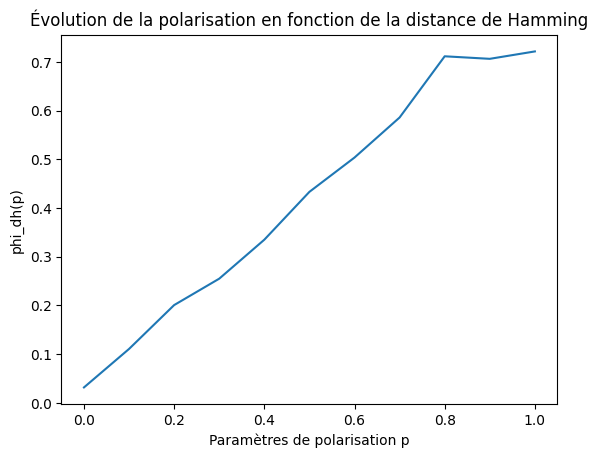

In [15]:
import matplotlib.pyplot as plt

nb_tests = 100
niveaux_polarisation = [k/10 for k in range (11)]

phi = [] #on cree une liste pour pouvoir enregistrer les différentes valeurs données

for polarisation in niveaux_polarisation:
    moyenne = 0
    for n in range (nb_tests):
        p = generer_approbation_profil(20, 5, polarisation)
        moyenne += phi_hamming(p)
    phi.append(moyenne/nb_tests)

plt.plot(niveaux_polarisation, phi)
plt.xlabel("Paramètres de polarisation p")
plt.ylabel("phi_dh(p)")
plt.title("Évolution de la polarisation en fonction de la distance de Hamming")
plt.show()

### Évolution des mesures 𝜑_ds

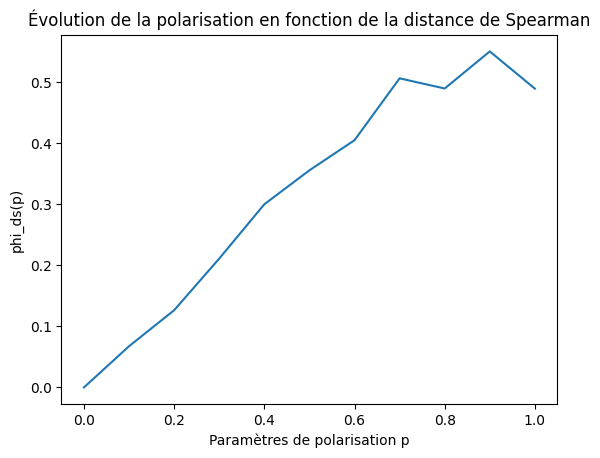

In [16]:
nb_tests = 100
niveaux_polarisation = [k/10 for k in range (11)]

phi = [] #on cree une liste pour pouvoir enregistrer les différentes valeurs données

for polarisation in niveaux_polarisation:
    moyenne = 0
    for n in range(nb_tests):
        p = generer_ordre_profil(20, 6, polarisation)
        moyenne += phi_spearman(p)
    phi.append(moyenne/nb_tests)

plt.plot(niveaux_polarisation, phi)
plt.xlabel("Paramètres de polarisation p")
plt.ylabel("phi_ds(p)")
plt.title("Évolution de la polarisation en fonction de la distance de Spearman")
plt.show()